# Data cleaning

#### Hands-on 1

In [1]:
import pandas as pd
import numpy as np

In [2]:
data = {"Name":["Alice","Bob",np.nan,"David"],"Age":[30,np.nan,35,25],"Score":[87,89,98,np.nan]}

In [3]:
df = pd.DataFrame(data)

In [4]:
print(df)

    Name   Age  Score
0  Alice  30.0   87.0
1    Bob   NaN   89.0
2    NaN  35.0   98.0
3  David  25.0    NaN


In [5]:
df["Age"]=df["Age"].fillna(df["Age"].mean())

In [6]:
df["Score"]=df["Score"].interpolate()

In [7]:
df = df.rename(columns = {"Name":"Student_names","Score":"Exam:Score"})

In [8]:
print("dataset: \n ",df)

dataset: 
    Student_names   Age  Exam:Score
0         Alice  30.0        87.0
1           Bob  30.0        89.0
2           NaN  35.0        98.0
3         David  25.0        98.0


#### Hands-on 2

In [9]:
df1 = pd.DataFrame({"ID":[1,2,3],"Name":["Alice","Bob","david"],"Age":[30,35,25]})
df2 = pd.DataFrame({"ID":[1,2,3],"Score":[80,85,75]})

In [11]:
print("dataset1: \n ",df1)
print("\n dataset2: \n ",df2)

dataset1: 
     ID   Name  Age
0   1  Alice   30
1   2    Bob   35
2   3  david   25

 dataset2: 
     ID  Score
0   1     80
1   2     85
2   3     75


In [13]:
merged = pd.merge(df1,df2,how = "inner",on="ID")
print(merged)

   ID   Name  Age  Score
0   1  Alice   30     80
1   2    Bob   35     85
2   3  david   25     75


In [14]:
merged = pd.merge(df1,df2,how = "left",on="ID")
print(merged)

   ID   Name  Age  Score
0   1  Alice   30     80
1   2    Bob   35     85
2   3  david   25     75


In [16]:
merged["Score_percentage"] = (merged["Score"]/100)*100
print("transformed_dataset: \n ",merged)

transformed_dataset: 
     ID   Name  Age  Score  Score_percentage
0   1  Alice   30     80              80.0
1   2    Bob   35     85              85.0
2   3  david   25     75              75.0


In [18]:
merged["Age_after_2_yeras"] = merged["Age"]+2
print(merged)

   ID   Name  Age  Score  Score_percentage  Age_after_2_yeras
0   1  Alice   30     80              80.0                 32
1   2    Bob   35     85              85.0                 37
2   3  david   25     75              75.0                 27


In [20]:
# concatenation
concatenated1 = pd.concat([df1,df2],axis = 0)
concatenated2 = pd.concat([df1,df2],axis = 1)
print(concatenated1)
print(concatenated2)

   ID   Name   Age  Score
0   1  Alice  30.0    NaN
1   2    Bob  35.0    NaN
2   3  david  25.0    NaN
0   1    NaN   NaN   80.0
1   2    NaN   NaN   85.0
2   3    NaN   NaN   75.0
   ID   Name  Age  ID  Score
0   1  Alice   30   1     80
1   2    Bob   35   2     85
2   3  david   25   3     75


In [24]:
concatenated1 = concatenated1.drop_duplicates(subset = "ID",keep = "first")
print(concatenated1)

   ID   Name   Age  Score
0   1  Alice  30.0    NaN
1   2    Bob  35.0    NaN
2   3  david  25.0    NaN


In [27]:
concatenated2 = concatenated2.loc[:,concatenated2.columns.duplicated()]
print(concatenated2)

   ID
0   1
1   2
2   3


In [29]:
concatenated2 = pd.merge(concatenated1,concatenated2,how = "inner",on="ID")

In [31]:
print(dataset1)

   ID   Name   Age  Score
0   1  Alice  30.0    NaN
1   2    Bob  35.0    NaN
2   3  david  25.0    NaN


# Data aggregation

In [4]:
import pandas as pd
data = {"Class":["A","B","A","B","C","C"],"Age":[19,17,16,18,15,16],"Score":[87,54,66,98,67,95]}
print(data)

{'Class': ['A', 'B', 'A', 'B', 'C', 'C'], 'Age': [19, 17, 16, 18, 15, 16], 'Score': [87, 54, 66, 98, 67, 95]}


In [5]:
df = pd.DataFrame(data)
print(df)

  Class  Age  Score
0     A   19     87
1     B   17     54
2     A   16     66
3     B   18     98
4     C   15     67
5     C   16     95


In [16]:
#group data by categorical column
grouped = df.groupby("Class").mean()
print(grouped)

        Age  Score
Class             
A      17.5   76.5
B      17.5   76.0
C      15.5   81.0


In [8]:
grouped = df.groupby("Class")["Age"].mean()
print(grouped)

Class
A    17.5
B    17.5
C    15.5
Name: Age, dtype: float64


In [14]:
grouped = df.groupby("Class").agg({"Age":["mean","max","min"],"Score":["mean","max","min"]})
print(grouped)

        Age         Score        
       mean max min  mean max min
Class                            
A      17.5  19  16  76.5  87  66
B      17.5  18  17  76.0  98  54
C      15.5  16  15  81.0  95  67


In [15]:
# calculating summary statistics
stats = df.groupby("Class").agg({"Age":["mean","max","min"],"Score":["mean","max","min"]})
print(stats)

        Age         Score        
       mean max min  mean max min
Class                            
A      17.5  19  16  76.5  87  66
B      17.5  18  17  76.0  98  54
C      15.5  16  15  81.0  95  67


# Data Visualization

In [1]:
import matplotlib.pyplot as plt

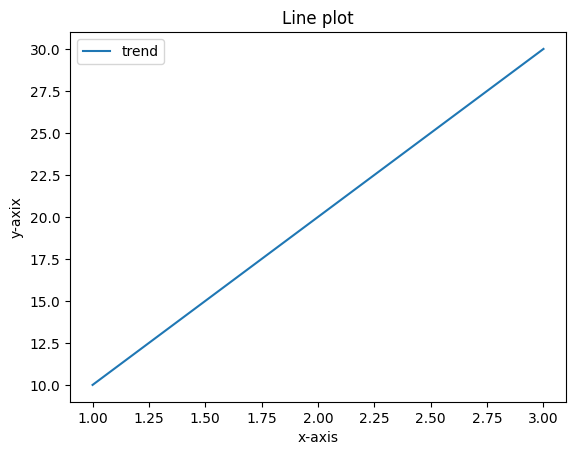

In [2]:
x = [1,2,3]
y = [10,20,30]
plt.plot(x,y,label = "trend")
plt.title ("Line plot")
plt.xlabel("x-axis")
plt.ylabel("y-axix")
plt.legend()
plt.show()

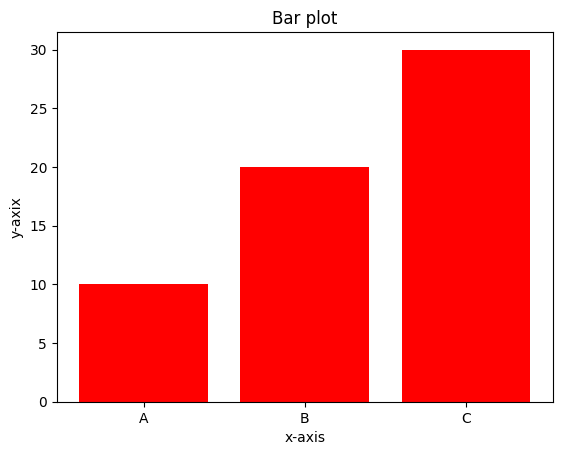

In [14]:
categories = ["A","B","C"]
values = [10,20,30]
plt.bar(categories,values,color = "red")
plt.title ("Bar plot")
plt.xlabel("x-axis")
plt.ylabel("y-axix")

plt.show()

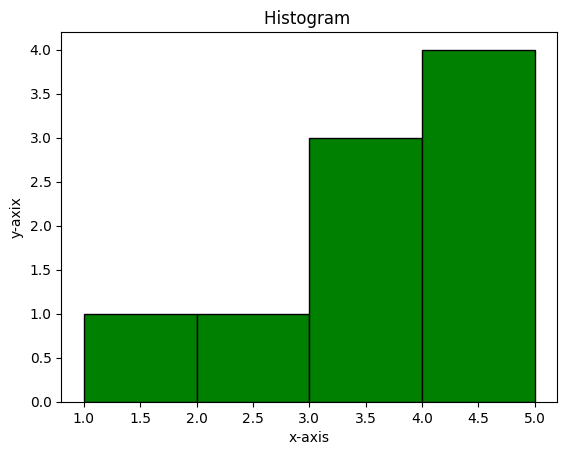

In [13]:
data = [1,2,3,3,3,4,4,4,5]
plt.hist(data,bins = 4,color = "green",edgecolor = "black")
plt.title ("Histogram ")
plt.xlabel("x-axis")
plt.ylabel("y-axix")
plt.show()

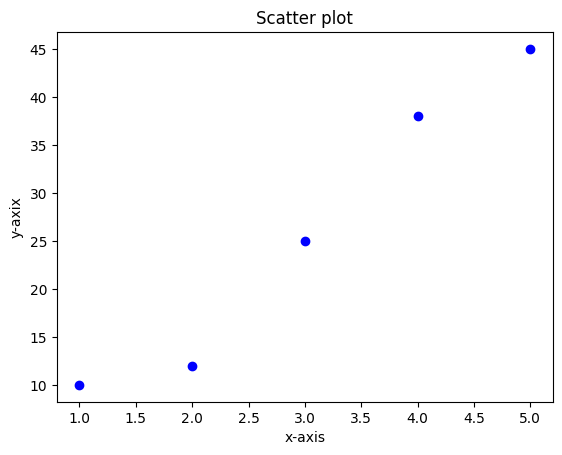

In [12]:
x = [1,2,3,4,5]
y = [10,12,25,38,45]
plt.scatter(x,y,color = "blue")
plt.title ("Scatter plot")
plt.xlabel("x-axis")
plt.ylabel("y-axix")
plt.show()

## seaborn

In [11]:
import seaborn as sns
import pandas as pd
import numpy as np

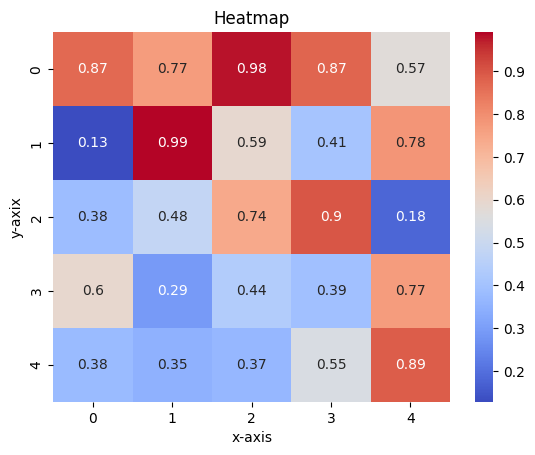

In [19]:
#Heatmap for visualizing matrix data
data = np.random.rand(5,5)
sns.heatmap(data,annot =True,cmap = "coolwarm")
plt.title ("Heatmap")
plt.xlabel("x-axis")
plt.ylabel("y-axix")

plt.show()